In [1]:
import os


from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("IsraelvsPalestineAnalysis") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark session created successfully")

Spark session created successfully


In [2]:
import pandas
from pyspark import *
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
import plotly.graph_objects as go

In [3]:
def df2freq(df, group_cols, collect_sets=None):
    agg_exprs = [F.count("*").alias("count")]

    if collect_sets:
        agg_exprs.append(F.collect_set(collect_sets).alias(f"{collect_sets}_set"))

    # Sort first by count in descending order, then by group_cols in descending order for tie-breaking
    sort_cols = [F.desc('count')] + [F.desc(col) for col in group_cols]
    return df.groupBy(*group_cols).agg(*agg_exprs).sort(*sort_cols).toPandas()

# Social Media - Youtube API

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import glob

file_pattern = r"/content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_*.csv"
csv_files = glob.glob(file_pattern)

all_pandas_dfs = []

if not csv_files:
    print(f"No files found matching the pattern: {file_pattern}")
else:
    print(f"Found {len(csv_files)} files to process.")
    for file_path in csv_files:
        try:
            df = pandas.read_csv(file_path, parse_dates=['video_publish_date', 'comment_date'])
            # Rename the column using Pandas before converting to Spark
            if 'Unnamed: 0' in df.columns:
                df = df.rename(columns={"Unnamed: 0": "No"})
            all_pandas_dfs.append(df)
            print(f"Processed {file_path}")
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    if all_pandas_dfs:
        combined_pandas_df = pandas.concat(all_pandas_dfs, ignore_index=True)
        youtube_df = spark.createDataFrame(combined_pandas_df)
        print(f"Successfully combined {len(csv_files)} CSV files into youtube_df with {youtube_df.count()} rows.")
    else:
        print("No dataframes were successfully processed to combine.")

df = youtube_df

Found 45 files to process.
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2025-09-08.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2025-12-13.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2026-02-22.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2026-03-12.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2026-03-14.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2026-03-15.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_youtube_2026-04-04.csv
Processed /content/drive/MyDrive/Colab Notebooks/Classified_Youtube_Comments/classification_comments_yout

In [6]:
print(df.count())

272338


In [8]:
# Counting how active the authors of comments are. Here we can see that 1 out of 3 authors written more than 1 comments.
people_df = youtube_df.groupby('comment_author_name').agg(F.count('comment_author_name').alias('comment_author_count'), \
                                                          F.collect_set('classification').alias('classifications'), F.sum('comment_likes').alias('author_sum_likes'))
people_df = people_df.withColumn('more_than_one_comment_for_author', F.when((F.col('comment_author_count') > 1), True).otherwise(False))
print("The total number of classified comments is:")
print(youtube_df.count())
print("Total number of people who commented once:")
print(people_df.filter(F.col('more_than_one_comment_for_author') == False).count())
print("The number of comments that comes from a people who have commented more than once is:")
print(int(youtube_df.count()) - int(people_df.filter(F.col('more_than_one_comment_for_author') == False).count()))
df2freq(people_df, ['more_than_one_comment_for_author'])

The total number of classified comments is:
272338
Total number of people who commented once:
116033
The number of comments that comes from a people who have commented more than once is:
156305


,more_than_one_comment_for_author,count
0,False,116033
1,True,46722


In [9]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# Step 1: Calculate the count of each classification for every comment_author_name from youtube_df
author_comment_classification_counts = youtube_df.groupBy("comment_author_name", "classification") \
                                                 .agg(F.count("*").alias("classification_count"))

# Step 2: For authors with multiple classifications, identify the dominant one.
# Use a window function to rank classifications by count in descending order, with classification name as a tie-breaker.
window_spec_row_number = Window.partitionBy("comment_author_name").orderBy(F.desc("classification_count"), F.asc("classification"))
dominant_classifications = author_comment_classification_counts.withColumn("row_num", F.row_number().over(window_spec_row_number)) \
                                                                .filter(F.col("row_num") == 1) \
                                                                .select("comment_author_name", F.col("classification").alias("dominant_classification"))

# Step 3: Join people_df with dominant_classifications
people_df = people_df.join(dominant_classifications, on="comment_author_name", how="left")

# Step 4: Create the final_classification column in people_df
# If an author has only one unique classification, use that one. Otherwise, use the dominant_classification.
people_df = people_df.withColumn(
    "final_classification",
    F.when(F.size(F.col("classifications")) == 1, F.col("classifications")[0])
     .otherwise(F.col("dominant_classification"))
)

print("Final classification column added to people_df.")

Final classification column added to people_df.


In [10]:
from pyspark.sql.window import Window

# Step 1: Count identical comments for each author and comment combination
identical_comments_counts = youtube_df.groupBy("comment_author_name", "full_comment") \
                                      .agg(F.count("*").alias("identical_comment_count"))

# Step 2: Find the maximum identical comment count for each author
# Use a window function to find the maximum 'identical_comment_count' for each author
window_spec_author = Window.partitionBy("comment_author_name")
max_identical_comments = identical_comments_counts.withColumn(
    "max_identical_comments_by_author",
    F.max("identical_comment_count").over(window_spec_author)
).select("comment_author_name", "max_identical_comments_by_author").distinct()

# Step 3: Join this back to people_df
people_df = people_df.join(max_identical_comments, on="comment_author_name", how="left")

print("Added 'max_identical_comments_by_author' to people_df.")

Added 'max_identical_comments_by_author' to people_df.


In [11]:
# Here we determine if likely_a_bot by haveing more then 5 comments
# Plus at least 30% of comments are identical
# Otherwise not likely_a_bot by this test.
people_df = people_df.withColumn(
    'likely_a_bot',
    (F.col('comment_author_count') > 5) & ((F.col('max_identical_comments_by_author') / F.col('comment_author_count')) > 0.3)
)
df2freq(people_df, ['likely_a_bot'])

,likely_a_bot,count
0,False,160978
1,True,1777


In [12]:
# Some info about the 'likely a bot' users:
people_df.filter((F.col('likely_a_bot'))).select(F.count('likely_a_bot'),F.sum('comment_author_count'), F.sum('author_sum_likes')).show()

+-------------------+-------------------------+---------------------+
|count(likely_a_bot)|sum(comment_author_count)|sum(author_sum_likes)|
+-------------------+-------------------------+---------------------+
|               1777|                    17144|                95369|
+-------------------+-------------------------+---------------------+



### Identifying Potential Bots by Username


In this approach we'll check if a username, or parts of it, contain recognized words from a dictionary. This helps differentiate names that might seem random but contain actual words (e.g., TravelLover, CodeMonkey) from truly random or auto-generated strings that looks totaly 'botish' (e.g., xY7zP9qR).

We'll use the library pyenchant.

In [15]:
# Update package lists and install the underlying C library for enchant
!sudo apt-get update
!sudo apt-get install -y libenchant-2-dev # Changed from 'enchant' to 'libenchant-2-dev'

# Install pyenchant (if not already installed)
!pip install pyenchant

import enchant

# Initialize an English dictionary
# You can choose other dictionaries like 'en_GB' or 'es' if relevant
d = enchant.Dict("en_US")

def contains_real_word(username):
    # Clean the username: remove special characters, numbers, and convert to lowercase
    cleaned_username = ''.join(filter(str.isalpha, username)).lower()

    # Split into potential words. This is a heuristic and might need refinement.
    # For simplicity, we'll try to find any sub-string that's a word.
    # More advanced methods would involve tokenizing or using a sub-word tokenizer.
    for i in range(len(cleaned_username)):
        for j in range(i + 3, len(cleaned_username) + 1): # Check words of at least 3 characters
            sub_string = cleaned_username[i:j]
            if d.check(sub_string):
                return True
    return False

# Apply the function to the comment_author_name column
# Note: This operation can be slow on large Spark DataFrames if not optimized.
# For demonstration, we'll convert to Pandas and then back to Spark.

pdf_people = people_df.toPandas()
pdf_people['contains_real_word'] = pdf_people['comment_author_name'].apply(contains_real_word)

# Convert back to Spark DataFrame
people_df_with_words = spark.createDataFrame(pdf_people)

print("Distribution of usernames containing real words:")
display(people_df_with_words.groupBy('contains_real_word').count().toPandas())

print("\nExamples of usernames likely containing real words:")
display(people_df_with_words.filter(F.col('contains_real_word') == True).limit(10).toPandas())

print("\nExamples of usernames likely NOT containing real words (more 'gibberish'):")
display(people_df_with_words.filter(F.col('contains_real_word') == False).limit(10).toPandas())

Distribution of usernames containing real words:


,contains_real_word,count
0,True,135967
1,False,26788



Examples of usernames likely containing real words:


,comment_author_name,comment_author_count,classifications,author_sum_likes,more_than_one_comment_for_author,dominant_classification,final_classification,max_identical_comments_by_author,likely_a_bot,contains_real_word
0,@--gad-telaviv3600,1,[support_israel],2,False,support_israel,support_israel,1,False,True
1,@--tsatsa--,1,[support_israel],0,False,support_israel,support_israel,1,False,True
2,@-Azad-Vlogs,1,[support_israel],0,False,support_israel,support_israel,1,False,True
3,@-Migo-leo-,1,[support_israel],0,False,support_israel,support_israel,1,False,True
4,@-MiralBelalSharaf,1,[support_palestine],0,False,support_palestine,support_palestine,1,False,True
5,@-S.a.r.a.h-,1,[support_israel],27,False,support_israel,support_israel,1,False,True
6,@-SoulSimulation-,1,[support_israel],0,False,support_israel,support_israel,1,False,True
7,@-UnBall,1,[support_israel],0,False,support_israel,support_israel,1,False,True
8,@-almotera,1,[support_palestine],1,False,support_palestine,support_palestine,1,False,True
9,@-ammaryasser9313,1,[support_palestine],0,False,support_palestine,support_palestine,1,False,True



Examples of usernames likely NOT containing real words (more 'gibberish'):


,comment_author_name,comment_author_count,classifications,author_sum_likes,more_than_one_comment_for_author,dominant_classification,final_classification,max_identical_comments_by_author,likely_a_bot,contains_real_word
0,@---km6gc,1,[support_palestine],0,False,support_palestine,support_palestine,1,False,False
1,@-.44maeda-4,2,[support_palestine],2,True,support_palestine,support_palestine,1,False,False
2,@-EvoII-,1,[support_israel],0,False,support_israel,support_israel,1,False,False
3,@-IBI-,4,[support_palestine],0,True,support_palestine,support_palestine,3,False,False
4,@-TIGR,1,[support_israel],0,False,support_israel,support_israel,1,False,False
5,@-mw9ld,1,[support_palestine],0,False,support_palestine,support_palestine,1,False,False
6,@-rei1287,1,[support_palestine],0,False,support_palestine,support_palestine,1,False,False
7,@-syahmi6924,1,[support_palestine],1,False,support_palestine,support_palestine,1,False,False
8,@-taiboun8152,2,[support_palestine],19,True,support_palestine,support_palestine,1,False,False
9,@-ul7lh,2,[support_israel],0,True,support_israel,support_israel,2,False,False


### Combining Heuristics

Now we take the two signals for bot detection: `likely_a_bot` (based on many comments that are identical) and `contains_real_word` (based on lexical content). We try to combine these to create a more comprehensive 'human-like' score for classification.

For example, a username that is *not* `likely_a_bot` and *does* `contains_real_word` is more likely to be a real human.


In [17]:
people_df = people_df_with_words

# Example of combining the heuristics:
people_df = people_df.withColumn(
    'Probably_Human',
    (F.col('likely_a_bot') == False) & (F.col('contains_real_word') == True)
)

print("Distribution of 'Probably_Human':")
display(people_df.groupBy('Probably_Human').count().toPandas())

Distribution of 'Probably_Human':


,Probably_Human,count
0,True,134457
1,False,28298


### Determining a Final Classification for Each Author

To assign a single `final_classification` to each author, especially for those with comments previously classified into multiple categories (e.g., both 'support_israel' and 'support_palestine'), we need to determine the most frequent classification among their comments. This will resolve ambiguities and provide a clearer overall stance for each author.

The logic will be:
1.  **For authors with only one unique classification** across all their comments, that single classification will be their `final_classification`.
2.  **For authors with multiple unique classifications**, we will count the occurrences of each classification for that author in the original `youtube_df` and assign the most frequent one as their `final_classification`.

### Sample of Authors with their Final Classification

Let's display a sample of the `people_df` to see the new `final_classification` column in action, alongside the original `classifications` array.

In [18]:
# THIS GRAPH SHOWS CLASSIFICATION DIVIDED BY VIDEOS'S YEAR PUBLISH

import plotly.io as pio
pio.renderers.default = 'colab'  # Changed to 'colab' for better Colab compatibility

# Extract publish_year
df = df.withColumn("publish_year", F.split("video_publish_date", "-")[0])

# Count per year & classification
df_counts = df.groupBy("publish_year", "classification").count()

# Pivot to wide format for plotting
df_pivot = df_counts.groupBy("publish_year").pivot("classification").agg(F.first("count")).fillna(0)

# Collect to Pandas for plotting
pdf = df_pivot.toPandas().sort_values("publish_year")

# Create Plotly figure
fig = go.Figure()

for cls in [c for c in pdf.columns if c != "publish_year"]:
    fig.add_trace(go.Bar(
        x=pdf["publish_year"],
        y=pdf[cls],
        name=cls,
        text=pdf[cls],  # Hover data
        textposition='auto',  # Show values on bars
        hovertemplate='Year: %{x}<br>Count: %{y}<extra></extra>'
    ))

fig.update_layout(
    title="Number of Classifications per Publish video year",
    xaxis_title="Year",
    yaxis_title="Count",
    barmode='group'
)

fig.show()

In [19]:
# THIS GRAPH SHOWS CLASSIFICATION DIVIDED BY COMMENT'S YEAR

import plotly.io as pio
pio.renderers.default = 'colab'  # Changed to 'colab' for better Colab compatibility

# Extract comment_date
df = df.withColumn("comment_year", F.split("comment_date", "-")[0])

# Count per year & classification
df_counts = df.groupBy("comment_year", "classification").count()

# Pivot to wide format for plotting
df_pivot = df_counts.groupBy("comment_year").pivot("classification").agg(F.first("count")).fillna(0)

# Collect to Pandas for plotting
pdf = df_pivot.toPandas().sort_values("comment_year")

# Create Plotly figure
fig = go.Figure()

for cls in [c for c in pdf.columns if c != "comment_year"]:
    fig.add_trace(go.Bar(
        x=pdf["comment_year"],
        y=pdf[cls],
        name=cls,
        text=pdf[cls],  # Hover data
        textposition='auto',  # Show values on bars
        hovertemplate='Year: %{x}<br>Count: %{y}<extra></extra>'
    ))

fig.update_layout(
    title="Number of Classifications per Publish comment year",
    xaxis_title="Year",
    yaxis_title="Count",
    barmode='group'
)

fig.show()

In [20]:
import plotly.graph_objects as go
import plotly.io as pio
from pyspark.sql import functions as F

pio.renderers.default = 'colab'

# 1. Extract the year from the comment_date
# Assuming format is YYYY-MM-DD... we split by '-' and take the first part
df_with_year = df.withColumn("comment_year", F.split(F.col("comment_date"), "-")[0])

# 2. Aggregate: Group by year and classification, then SUM the likes
df_likes = df_with_year.groupBy("comment_year", "classification") \
                       .agg(F.sum("comment_likes").alias("total_likes"))

# 3. Pivot to wide format for Plotly
df_pivot = df_likes.groupBy("comment_year") \
                   .pivot("classification") \
                   .agg(F.first("total_likes")) \
                   .fillna(0)

# 4. Collect to Pandas and sort
pdf = df_pivot.toPandas().sort_values("comment_year")

# 5. Create Plotly figure
fig = go.Figure()

# Loop through the columns (classifications) to add bars
for cls in [c for c in pdf.columns if c != "comment_year"]:
    fig.add_trace(go.Bar(
        x=pdf["comment_year"],
        y=pdf[cls],
        name=cls,
        text=pdf[cls],
        textposition='auto',
        hovertemplate='Year: %{x}<br>Total Likes: %{y}<extra></extra>'
    ))

fig.update_layout(
    title="Total Likes per Classification divided by comment year",
    xaxis_title="Year",
    yaxis_title="Sum of Comment Likes",
    barmode='group',
    legend_title="Classification",
    template="plotly_white"
)

fig.show()

The `percentage_difference_palestine_vs_israel` column shows the relative difference in likes each year. A positive value indicates stronger support for Palestine, a negative value indicates stronger support for Israel, and a value close to zero means similar levels of support.

Now, let's visualize this trend to observe how this percentage difference has changed over the years.

In [21]:
import pandas as pd
from pyspark.sql import functions as F
import plotly.graph_objects as go
import plotly.io as pio

# Ensure 'comment_year' column exists and is cast to integer
df_with_year_for_corr = df.withColumn("comment_year_int", F.split("comment_date", "-")[0].cast("int"))

# Group by year and classification, then count the comments
df_aggregated_comments = df_with_year_for_corr.groupBy("comment_year_int", "classification") \
                                            .agg(F.count("*").alias("comment_count")) \
                                            .toPandas()

# Pivot the df_aggregated_comments DataFrame to have years as index and classifications as columns
comparison_df = df_aggregated_comments.pivot(index='comment_year_int', columns='classification', values='comment_count').fillna(0)

# Calculate the yearly percentage difference (Palestine vs. Israel)
# This calculation (P-I)/(P+I) ranges from -1 (all Israel) to +1 (all Palestine)
# We'll multiply by 100 for a percentage. Handle cases where sum is zero.
comparison_df['total_comments_sum'] = comparison_df['support_palestine'] + comparison_df['support_israel']
comparison_df['percentage_difference_palestine_vs_israel'] = comparison_df.apply(
    lambda row:
        ((row['support_palestine'] - row['support_israel']) / row['total_comments_sum']) * 100
        if row['total_comments_sum'] != 0 else 0,
    axis=1
)
pio.renderers.default = 'colab'

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=comparison_df.index,
    y=comparison_df['percentage_difference_palestine_vs_israel'],
    mode='lines+markers',
    name='Percentage Difference (Palestine vs Israel)',
    line=dict(color='purple', width=3),
    marker=dict(size=6)
))

fig.update_layout(
    title="Yearly Percentage Difference in Comment Counts (Palestine vs Israel)",
    xaxis_title="Year",
    yaxis_title="Percentage Difference (Palestine - Israel) / (Palestine + Israel) * 100",
    template="plotly_white",
    legend=dict(x=0, y=1, bgcolor="rgba(0,0,0,0)"),
    hovermode="x unified"
)

fig.show()


The plot above illustrates the yearly fluctuations in the relative strength of 'support Palestine' versus 'support Israel' based on comment likes. By examining this graph, we can identify years where one side gained significantly more engagement than the other, and observe any long-term trends or shifts in public sentiment over the dataset's duration.

In [22]:
df.groupBy("classification").agg(F.count("classification")).toPandas()

,classification,count(classification)
0,support_israel,127482
1,support_palestine,144856


In [23]:
# Top 20 videos classified with most likes:
df.groupBy("video_id", "classification").agg(F.sum("comment_likes")).sort(F.desc('sum(comment_likes)')).limit(20).toPandas()

,video_id,classification,sum(comment_likes)
0,VaXfCqGR0sI,support_palestine,48738
1,foSbqLi6U10,support_palestine,47724
2,dlfhoU66s4Y,support_palestine,29849
3,G9030zb-s5Q,support_palestine,15135
4,XTWb0SH6jMw,support_israel,10378
5,2klwFNhs1rc,support_palestine,9857
6,TZCa2qdyHNk,support_palestine,9576
7,bP5Zj4V7gi4,support_palestine,7614
8,gZ9g_3BHsRs,support_palestine,7179
9,L-Fzan-VWO0,support_palestine,6530


# Google Trends

In [ ]:
"""
Cross-term comparisons

You can compare "Israel" vs "Palestine" on the same day because they’re normalized in the same query.

Example: On 2024-01-12, "Israel" had 100 while "Palestine" had 25 — meaning "Israel" was searched about 4× more than "Palestine" that day.

But if you run a separate query with only "Palestine", the numbers will be rescaled and no longer directly comparable to "Israel"’s numbers from this run.
"""

In [ ]:
pip install pytrends

In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

def get_normalized_trends(keywords, start_date, end_date, anchor, geo="", sleep_time=2):
    pytrends = TrendReq(hl='en-US', tz=0)
    timeframe = f"{start_date} {end_date}"

    # Split into chunks of max 5 keywords including the anchor
    chunks = []
    for i in range(0, len(keywords), 4):  # 4 because anchor takes 1 spot
        chunk = [anchor] + [kw for kw in keywords[i:i+4] if kw != anchor]
        chunks.append(chunk)

    anchor_df = None
    all_data = []

    for idx, chunk in enumerate(chunks):
        print(f"Fetching chunk {idx+1}/{len(chunks)}: {chunk}")
        pytrends.build_payload(chunk, timeframe=timeframe, geo=geo)
        df = pytrends.interest_over_time().drop(columns=['isPartial'])

        if anchor_df is None:
            anchor_df = df[[anchor]]
            all_data.append(df)
        else:
            # Scale this chunk's anchor to match the master anchor_df
            scaling_factor = anchor_df[anchor].mean() / df[anchor].mean()
            df_scaled = df.copy()
            for col in df.columns:
                if col != 'date':
                    df_scaled[col] = df[col] * scaling_factor
            all_data.append(df_scaled.drop(columns=[anchor]))

        time.sleep(sleep_time)  # avoid rate limit

    # Merge all chunks on the date index
    final_df = pd.concat(all_data, axis=1)
    final_df = final_df.loc[:, ~final_df.columns.duplicated()]
    return final_df

In [ ]:
# Example usage
keywords = ["israel", "palestine", "hamas", "idf", "gaza", "iran"]
trends_df = get_normalized_trends(keywords, "2023-08-01", "2026-04-23", anchor="israel", sleep_time=3)
trends_df = trends_df.reset_index()  # if the date is the index
trends_df = spark.createDataFrame(trends_df)

Fetching chunk 1/2: ['israel', 'palestine', 'hamas', 'idf']


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Fetching chunk 2/2: ['israel', 'gaza', 'iran']


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
trends_df.sort('israel', ascending=False).limit(50).toPandas()

,date,israel,palestine,hamas,idf,gaza,iran
0,2023-10-08,100,24,35,1,23.787196,4.757439
1,2023-10-15,46,14,12,1,14.272317,4.757439
2,2025-06-15,40,2,1,0,2.378720,55.899910
3,2026-03-01,29,2,1,1,2.378720,118.935978
4,2023-10-22,27,9,7,1,8.325518,3.568079
5,2025-06-22,27,2,1,1,2.378720,70.172227
6,2024-04-14,25,2,1,0,1.189360,22.597836
7,2023-10-29,24,9,6,1,7.136159,2.378720
8,2025-06-08,22,2,1,0,2.378720,23.787196
9,2024-09-29,22,2,1,1,1.189360,13.082958


In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

def plot_trends(spark_df):
    # Convert Spark DataFrame to Pandas
    pdf = spark_df.toPandas()

    # Make sure 'date' is in datetime format
    pdf['date'] = pd.to_datetime(pdf['date'])

    fig = go.Figure()

    # Israel line
    fig.add_trace(go.Scatter(
        x=pdf['date'],
        y=pdf['israel'],
        mode='lines+markers',
        name='Israel',
        line=dict(color='blue', width=3),
        marker=dict(size=6)
    ))

    # Palestine line
    fig.add_trace(go.Scatter(
        x=pdf['date'],
        y=pdf['palestine'],
        mode='lines+markers',
        name='Palestine',
        line=dict(color='orange', width=3),
        marker=dict(size=6)
    ))

    # Iran line
    fig.add_trace(go.Scatter(
        x=pdf['date'],
        y=pdf['iran'],
        mode='lines+markers',
        name='Iran',
        line=dict(color='Green', width=3),
        marker=dict(size=6)
    ))

    fig.update_layout(
        title="Google Trends: Israel vs Palestine (Peak Values Over Time)",
        xaxis_title="Date",
        yaxis_title="Relative Search Interest (0-100)",
        template="plotly_white",
        legend=dict(x=0, y=1, bgcolor="rgba(0,0,0,0)"),
        hovermode="x unified"
    )

    pio.show(fig)

# Example usage
# plot_trends(trends_df)


# Example usage:
# Assuming your df index is date and columns are lowercase
# df = get_google_trends(...)
plot_trends(trends_df)


# The GDLET Project

In [ ]:
from gdeltdoc import GdeltDoc, Filters

# Define filters
f = Filters(
    keyword="israel",
    start_date="2023-01-01",
    end_date="2023-12-31"
)

gd = GdeltDoc()

# Get normalized daily news volume percentage
timeline_pct = gd.timeline_search("timelinevol", f)

# Get raw counts of matching articles per day
timeline_raw = gd.timeline_search("timelinevolraw", f)

print(timeline_pct.head())
print(timeline_raw.head())


                   datetime  Volume Intensity
0 2023-01-01 00:00:00+00:00            1.2137
1 2023-01-02 00:00:00+00:00            1.4821
2 2023-01-03 00:00:00+00:00            1.3021
3 2023-01-04 00:00:00+00:00            1.1259
4 2023-01-05 00:00:00+00:00            0.9655
                   datetime  Article Count  All Articles
0 2023-01-01 00:00:00+00:00           1707        140639
1 2023-01-02 00:00:00+00:00           2914        196619
2 2023-01-03 00:00:00+00:00           3375        259205
3 2023-01-04 00:00:00+00:00           3173        281813
4 2023-01-05 00:00:00+00:00           2784        288347


In [ ]:
def gdlet_deep(topics, start_date, end_date, keywords=None):
    """
    Fetch and merge GKG data for multiple topics including:
    - Volume (mentions)
    - Tone (sentiment)
    - Source countries
    - Counts of specific words (optional, using article_search)
    Optionally filter by region for cross-source tone analysis.

    Args:
        topics: list of topic strings
        start_date, end_date: "YYYY-MM-DD"
        keywords: list of words to count in article titles (optional)
        regions: list of regions or countries for filtering (optional)

    Returns:
        Spark DataFrame with merged data
    """
    gd = GdeltDoc()
    all_dfs = []

    for topic in topics:
        # -------------------
        # 1. Volume
        # -------------------
        f_vol = Filters(keyword=topic, start_date=start_date, end_date=end_date)
        vol_df = gd.timeline_search("timelinevolraw", f_vol)
        if vol_df.empty:
            vol_df = pd.DataFrame({"datetime": [], f"{topic}_count": []})
        else:
            numeric_cols = vol_df.select_dtypes(include='number').columns
            if len(numeric_cols) == 0:
                vol_df = pd.DataFrame({"datetime": [], f"{topic}_count": []})
            else:
                vol_df = vol_df.rename(columns={numeric_cols[0]: f"{topic}_count"})
        # timezone-safe
        if "datetime" in vol_df.columns:
            vol_df["datetime"] = pd.to_datetime(vol_df["datetime"]).dt.tz_localize(None)

        # -------------------
        # 2. Tone
        # -------------------
        f_tone = Filters(keyword=topic, start_date=start_date, end_date=end_date)
        tone_df = gd.timeline_search("timelinetone", f_tone)
        if tone_df.empty:
            tone_df = pd.DataFrame({"datetime": [], f"{topic}_tone": []})
        else:
            possible_tone_cols = ["Tone", "Average Tone", "AvgTone"]
            tone_col = next((c for c in tone_df.columns if c in possible_tone_cols), None)
            if tone_col is None:
                numeric_cols = tone_df.select_dtypes(include='number').columns
                tone_col = numeric_cols[0] if len(numeric_cols) > 0 else None
            if tone_col is not None:
                tone_df = tone_df.rename(columns={tone_col: f"{topic}_tone"})
            else:
                tone_df[f"{topic}_tone"] = []
        if "datetime" in tone_df.columns:
            tone_df["datetime"] = pd.to_datetime(tone_df["datetime"]).dt.tz_localize(None)

        # -------------------
        # 3. Source countries
        # -------------------
        f_country = Filters(keyword=topic, start_date=start_date, end_date=end_date)
        country_df = gd.timeline_search("timelinesourcecountry", f_country)
        if country_df.empty:
            country_df = pd.DataFrame({"datetime": [], f"{topic}_source_country": [], f"{topic}_source_count": []})
        else:
            cols = list(country_df.columns)
            cols.remove("datetime")
            if len(cols) >= 2:
                country_df = country_df.rename(columns={cols[0]: f"{topic}_source_country", cols[1]: f"{topic}_source_count"})
            else:
                country_df[f"{topic}_source_country"] = None
                country_df[f"{topic}_source_count"] = None
        if "datetime" in country_df.columns:
            country_df["datetime"] = pd.to_datetime(country_df["datetime"]).dt.tz_localize(None)

        # -------------------
        # 4. Keyword counts via article_search
        # -------------------
        kw_counts_df = None
        if keywords:
            f_articles = Filters(keyword=topic, start_date=start_date, end_date=end_date)
            articles_df = gd.article_search(f_articles)

            if not articles_df.empty:
                for kw in keywords:
                    col_name = f"{topic}_count_{kw}"
                    if 'Title' in articles_df.columns:
                        articles_df[col_name] = articles_df['Title'].str.lower().str.count(kw.lower())
                    else:
                        articles_df[col_name] = 0

                # Ensure datetime column exists
                if "DATE" in articles_df.columns:
                    articles_df = articles_df.rename(columns={"DATE": "datetime"})
                elif "datetime" not in articles_df.columns:
                    articles_df["datetime"] = pd.to_datetime(start_date)
                else:
                    articles_df["datetime"] = pd.to_datetime(articles_df["datetime"])

                kw_cols = [f"{topic}_count_{kw}" for kw in keywords]
                kw_counts_df = articles_df.groupby("datetime")[kw_cols].sum().reset_index()
                kw_counts_df["datetime"] = pd.to_datetime(kw_counts_df["datetime"]).dt.tz_localize(None)

        # -------------------
        # Merge all topic-specific data
        # -------------------
        dfs_to_merge = [vol_df, tone_df, country_df]
        if kw_counts_df is not None:
            dfs_to_merge.append(kw_counts_df)

        merged_topic_df = dfs_to_merge[0]
        for df in dfs_to_merge[1:]:
            merged_topic_df = merged_topic_df.merge(df, on="datetime", how="outer")

        all_dfs.append(merged_topic_df)

    # -------------------
    # Merge all topics
    # -------------------
    merged_all = all_dfs[0]
    for df in all_dfs[1:]:
        merged_all = merged_all.merge(df, on="datetime", how="outer")

    merged_all_sorted = merged_all.sort_values("datetime")

    # -------------------
    # Convert to Spark
    # -------------------
    spark_df = spark.createDataFrame(merged_all_sorted)
    spark_df = spark_df.withColumn("datetime", F.to_timestamp("datetime"))

    return gdlet_structure(spark_df, keywords)


In [ ]:
# THIS IS THE CODE FOR CHANGING STRUCTURE SO IT WILL BE MORE ORGANIZED

def gdlet_structure(gdlet, keywords):
    # Collect all the country intensity columns
    country_cols = [c for c in gdlet.columns if c.endswith("Intensity_x")]

    # Build a struct with alias names
    country_struct = F.struct(
        *[F.col(c).alias(c.replace("Intensity_x", f"Intensity_{topics[0]}")) for c in country_cols]
    )

    # Add the struct column
    gdlet = gdlet.withColumn(f"country_intensity_{topics[0]}", country_struct)

    # Optionally drop the old wide columns
    gdlet = gdlet.drop(*country_cols)

    # Collect all the country intensity columns
    country_cols = [c for c in gdlet.columns if c.endswith("Intensity_y")]

    # Build a struct with alias names
    country_struct = F.struct(
        *[F.col(c).alias(c.replace("Intensity_y", f"Intensity_{topics[1]}")) for c in country_cols]
    )

    # Add the struct column
    gdlet = gdlet.withColumn(f"country_intensity_{topics[1]}", country_struct)

    # Optionally drop the old wide columns
    gdlet = gdlet.drop(*country_cols)

    # PART 2:

    if keywords:
        # Collect all the keywords intensity columns
        keyword_cols = [K for K in gdlet.columns if K.startswith(f"{topics[0]}_count_")]

        # Build a struct with alias names
        keyword_struct = F.struct(
            *[F.col(k) for k in keyword_cols]
        )

        # Add the struct column
        gdlet = gdlet.withColumn(f"{topics[0]}_count_keywords", keyword_struct)

        # Optionally drop the old wide columns
        gdlet = gdlet.drop(*keyword_cols)

        # Collect all the keywords intensity columns
        keyword_cols = [K for K in gdlet.columns if K.startswith(f"{topics[1]}_count_")]

        # Build a struct with alias names
        keyword_struct = F.struct(
            *[F.col(k) for k in keyword_cols]
        )

        # Add the struct column
        gdlet = gdlet.withColumn(f"{topics[1]}_count_keywords", keyword_struct)

        # Optionally drop the old wide columns
        gdlet = gdlet.drop(*keyword_cols)

    # PART 3:

    # Collect all the volume intensity columns
    vol_cols = [v for v in gdlet.columns if v.endswith("Volume Intensity")]

    gdlet = gdlet.drop(*vol_cols)

    gdlet = gdlet.drop("All Articles_x")
    gdlet = gdlet.withColumnRenamed("All Articles_y", "All Articles")

    return gdlet

In [ ]:
keywords = ["blockade", "occup", "self defense", "starv", "boycott", "assault", "peace"] # optional
regions = ["US", "UK", "DE"]  # optional

gdlet = gdlet_deep(
    topics=["israel", "palestine"],
    start_date="2023-08-01",
    end_date="2024-08-01"
    #keywords=keywords
)

In [ ]:
"""
Intensity ≠ hate/support.

It’s only telling you how conflictual vs cooperative an event is, not how it’s reported.

For your project, it’s best used as context, not as a stance signal.

"""

In [ ]:
gdlet.toPandas()

,datetime,Israel_count,Israel_tone,Israel_source_country,Israel_source_count,Palestine_count,All Articles,Palestine_tone,Palestine_source_country,Palestine_source_count,country_intensity_Israel,country_intensity_Palestine
0,2025-01-01,2762,-3.6134,0.0,0.0000,853,110544,-2.6457,0.5618,0.0000,"(0.0, 0.0, 1.3605, 2.0661, 0.2882, 0.1672, 0.2...","(0.0, 0.1362, 0.0, 0.0, 0.0, 1.6129, 0.7246, 0..."
1,2025-01-02,3835,-4.0324,0.0,0.0000,861,166479,-3.8647,0.1776,0.0000,"(0.0, 0.0, 6.4677, 3.7365, 2.6247, 0.0677, 3.6...","(2.0408, 0.201, 0.0, 0.0, 0.0, 12.037, 0.0, 0...."
2,2025-01-03,2975,-3.4850,0.0,1.6667,713,172746,-3.2513,0.3021,0.0000,"(0.0, 0.0, 3.1579, 3.3467, 2.439, 0.0, 1.5837,...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.107..."
3,2025-01-04,1827,-3.7475,0.0,2.7778,490,102004,-3.8151,0.5102,0.0000,"(0.0, 0.0, 2.9703, 2.0913, 0.0, 0.0395, 3.4908...","(0.0, 1.0017, 0.0, 0.0, 0.0, 4.8387, 0.8621, 0..."
4,2025-01-05,2203,-3.6442,0.0,2.9412,503,90987,-3.3018,0.3165,0.0000,"(7.6923, 0.0, 2.1277, 2.0353, 6.8548, 0.0465, ...","(0.0, 0.8591, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4038,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
191,2025-07-28,7307,-3.3544,0.0,2.6549,2361,217959,-2.3037,0.5747,0.0000,"(1.0204, 0.0, 5.3942, 5.102, 10.2334, 0.2188, ...","(1.0256, 1.2594, 0.0, 0.0, 0.0, 6.2069, 0.4049..."
192,2025-07-29,7144,-3.3296,0.0,1.5038,2852,195061,-2.1304,0.2410,1.1236,"(1.1765, 0.0, 5.6497, 5.0, 11.991, 0.1663, 9.2...","(3.0075, 2.3548, 0.0, 0.0, 0.0, 2.521, 1.0471,..."
193,2025-07-30,5932,-3.1490,0.0,1.2500,2676,207214,-2.3732,0.3846,2.0619,"(1.2195, 0.0, 3.9604, 3.856, 6.1441, 0.0578, 5...","(4.1096, 0.5348, 0.0, 0.2933, 0.0, 2.0979, 2.7..."
194,2025-07-31,5784,-2.9253,0.0,0.6211,2913,181361,-2.3184,0.4396,1.0417,"(0.0, 0.0, 4.9738, 5.4441, 10.0, 0.0925, 8.056...","(0.0, 1.5025, 0.0, 0.0, 0.0, 3.8095, 3.6232, 0..."


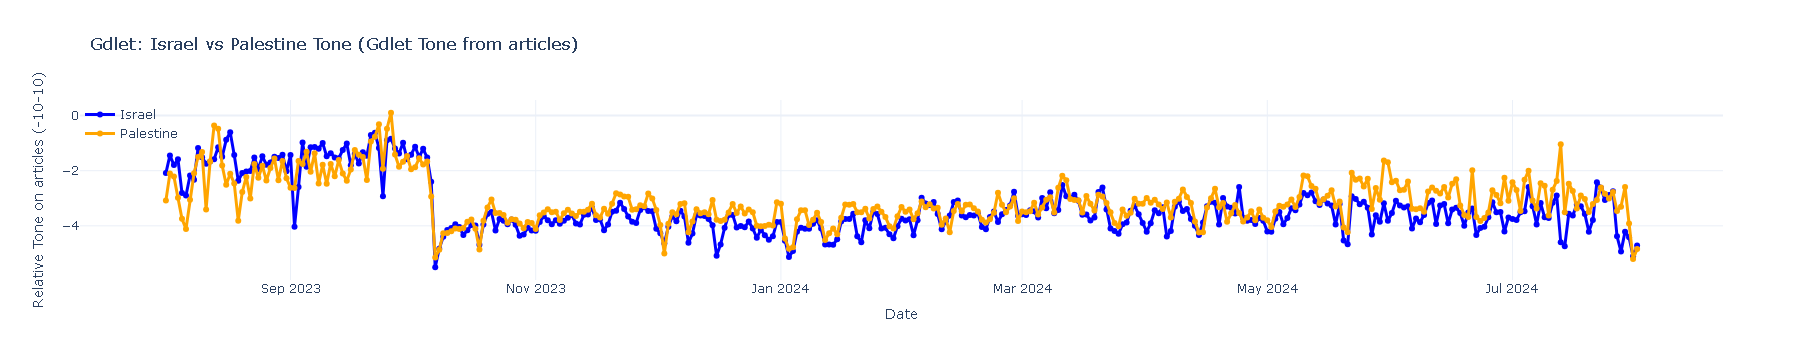

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

def plot_gdlet_tone(gdlet):

    # Convert to Pandas if it's still Spark DF
    if not isinstance(gdlet, pd.DataFrame):
        gdlet = gdlet.toPandas()

    # Make sure 'datetime' is in datetime format
    gdlet['datetime'] = pd.to_datetime(gdlet['datetime'])

    fig = go.Figure()

    # Israel line
    fig.add_trace(go.Scatter(
        x=gdlet['datetime'],
        y=gdlet['israel_tone'],
        mode='lines+markers',
        name='Israel',
        line=dict(color='blue', width=3),
        marker=dict(size=6)
    ))

    # Palestine line
    fig.add_trace(go.Scatter(
        x=gdlet['datetime'],
        y=gdlet['palestine_tone'],
        mode='lines+markers',
        name='Palestine',
        line=dict(color='orange', width=3),
        marker=dict(size=6)
    ))

    fig.update_layout(
        title="Gdlet: Israel vs Palestine Tone (Gdlet Tone from articles)",
        xaxis_title="Date",
        yaxis_title="Relative Tone on articles (-10-10)",
        template="plotly_white",
        legend=dict(x=0, y=1, bgcolor="rgba(0,0,0,0)"),
        hovermode="x unified"
    )

    pio.show(fig)

# Example usage
# plot_trends(trends_df)


# Example usage:
# Assuming your df index is date and columns are lowercase
# df = get_google_trends(...)
plot_gdlet_tone(gdlet)


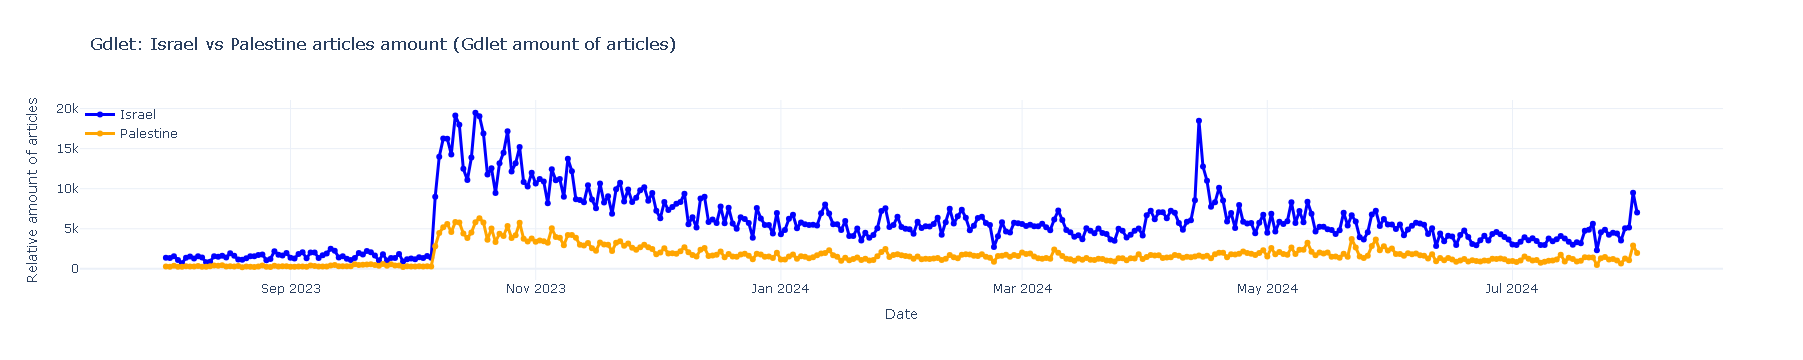

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

def plot_gdlet_articles(gdlet):

    # Convert to Pandas if it's still Spark DF
    if not isinstance(gdlet, pd.DataFrame):
        gdlet = gdlet.toPandas()

    # Make sure 'datetime' is in datetime format
    gdlet['datetime'] = pd.to_datetime(gdlet['datetime'])

    fig = go.Figure()

    # Israel line
    fig.add_trace(go.Scatter(
        x=gdlet['datetime'],
        y=gdlet['israel_count'],
        mode='lines+markers',
        name='Israel',
        line=dict(color='blue', width=3),
        marker=dict(size=6)
    ))

    # Palestine line
    fig.add_trace(go.Scatter(
        x=gdlet['datetime'],
        y=gdlet['palestine_count'],
        mode='lines+markers',
        name='Palestine',
        line=dict(color='orange', width=3),
        marker=dict(size=6)
    ))

    fig.update_layout(
        title="Gdlet: Israel vs Palestine articles amount (Gdlet amount of articles)",
        xaxis_title="Date",
        yaxis_title="Relative amount of articles",
        template="plotly_white",
        legend=dict(x=0, y=1, bgcolor="rgba(0,0,0,0)"),
        hovermode="x unified"
    )

    pio.show(fig)

# Example usage
# plot_trends(trends_df)


# Example usage:
# Assuming your df index is date and columns are lowercase
# df = get_google_trends(...)
plot_gdlet_articles(gdlet)


In [ ]:
spark_df.select("datetime", "Israel_count", "All Articles_x", "Israel_tone", "Israel_source_country",
                "Israel_source_count", "Israel_count_aggression", "Israel_count_occupation", "Israel_count_self-defense",
                "Palestine_count", "All Articles_y", "Palestine_tone", "Palestine_source_country", "Palestine_source_count" ,
                "Palestine_count_aggression", "Palestine_count_occupation", "Palestine_count_self-defense").toPandas()

,datetime,Israel_count,All Articles_x,Israel_tone,Israel_source_country,Israel_source_count,Israel_count_aggression,Israel_count_occupation,Israel_count_self-defense,Palestine_count,All Articles_y,Palestine_tone,Palestine_source_country,Palestine_source_count,Palestine_count_aggression,Palestine_count_occupation,Palestine_count_self-defense
0,2025-01-01,2762,110544,-3.6134,1.6162,5.5556,0.0,0.0,0.0,853,110544,-2.6457,0.0702,0.0000,0.0,0.0,0.0
1,2025-01-02,3835,166479,-4.0324,1.5476,2.5000,NaN,NaN,NaN,861,166479,-3.8647,0.0000,4.0000,NaN,NaN,NaN
2,2025-01-03,2975,172746,-3.4850,0.7003,2.2727,NaN,NaN,NaN,713,172746,-3.2513,0.0000,4.3478,NaN,NaN,NaN
3,2025-01-04,1827,102004,-3.7475,1.3393,2.5000,NaN,NaN,NaN,490,102004,-3.8151,0.0000,8.0000,NaN,NaN,NaN
4,2025-01-05,2203,90987,-3.6442,1.1682,5.5556,NaN,NaN,NaN,503,90987,-3.3018,0.0000,0.0000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,2025-07-28,7307,217959,-3.3544,3.6384,0.0000,NaN,NaN,NaN,2361,217959,-2.3037,0.0000,2.1277,NaN,NaN,NaN
192,2025-07-29,7144,195061,-3.3296,4.1835,5.5556,NaN,NaN,NaN,2852,195061,-2.1304,0.0262,4.3478,NaN,NaN,NaN
193,2025-07-30,5932,207214,-3.1490,2.9885,2.5641,NaN,NaN,NaN,2676,207214,-2.3732,0.0000,0.0000,NaN,NaN,NaN
194,2025-07-31,5784,181361,-2.9253,2.0359,2.1739,NaN,NaN,NaN,2913,181361,-2.3184,0.0000,1.9231,NaN,NaN,NaN


# News API

In [ ]:
# -----------------------
# IMPORTS
# -----------------------
import os
import time
import requests
import pandas as pd
import torch
from pyspark.sql.types import StructType, StructField, StringType
from transformers import pipeline

# -----------------------
# CONFIG
# -----------------------
NEWS_API_KEY = ""
QUERY = "Israel Palestine conflict"
MAX_ARTICLES = 500
PAGE_SIZE = 100
BATCH_SIZE = 12      # zero-shot is heavier; keep modest
SUPPORT_THRESH = 0.55
OPPOSE_THRESH  = 0.60
MARGIN = 0.08        # how much one side must beat the other

schema = StructType([
    StructField("title", StringType(), True),
    StructField("description", StringType(), True),
    StructField("content", StringType(), True),
    StructField("source", StringType(), True),
    StructField("url", StringType(), True),
    StructField("publishedAt", StringType(), True)
])

# ---------------------------
# FETCH ARTICLES (NewsAPI)
# ---------------------------
def fetch_articles(query, api_key, max_articles=500):
    url = "https://newsapi.org/v2/everything"
    all_articles, page = [], 1
    while len(all_articles) < max_articles:
        params = {
            "q": query, "apiKey": api_key, "pageSize": PAGE_SIZE,
            "page": page, "language": "en", "sortBy": "publishedAt"
        }
        r = requests.get(url, params=params, timeout=30)
        data = r.json()
        arts = data.get("articles", [])
        if not arts: break
        for a in arts:
            all_articles.append({
                "title": a.get("title"),
                "description": a.get("description"),
                "content": a.get("content"),
                "source": (a.get("source") or {}).get("name"),
                "url": a.get("url"),
                "publishedAt": a.get("publishedAt")
            })
            if len(all_articles) >= max_articles:
                break
        page += 1
        time.sleep(0.4)
        if len(arts) < PAGE_SIZE:  # last page
            break
    return all_articles[:max_articles]

print("Fetching articles...")
articles = fetch_articles(QUERY, NEWS_API_KEY, MAX_ARTICLES)
print(f"Fetched {len(articles)} articles.")

# ---------------------------
# CREATE SPARK DF (spark provided by your notebook)
# ---------------------------
df = spark.createDataFrame(pd.DataFrame(articles), schema=schema)

# ---------------------------
# ZERO-SHOT SETUP (CPU)
# ---------------------------
classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1     # CPU
)

entities = ["Israel", "Palestinians"]  # short, symmetric labels

def classify_support(texts):
    preds = classifier(
        texts,
        candidate_labels=entities,
        hypothesis_template="This text expresses support for {}.",
        multi_label=True,
        batch_size=BATCH_SIZE,
        truncation=True
    )
    if isinstance(preds, dict): preds = [preds]
    return [{lbl: scr for lbl, scr in zip(p["labels"], p["scores"])} for p in preds]

def classify_oppose(texts):
    preds = classifier(
        texts,
        candidate_labels=entities,
        hypothesis_template="This text expresses opposition to {}.",
        multi_label=True,
        batch_size=BATCH_SIZE,
        truncation=True
    )
    if isinstance(preds, dict): preds = [preds]
    return [{lbl: scr for lbl, scr in zip(p["labels"], p["scores"])} for p in preds]


def decide_stance(sI, sP, oI, oP):
    """Return (stance_label, stance_score)."""
    # Direct support wins if strong and with margin
    if max(sI, sP) >= SUPPORT_THRESH and abs(sI - sP) >= MARGIN:
        return ("support Israel", float(sI)) if sI > sP else ("support Palestine", float(sP))

    # Map clear one-sided opposition to the opposite support (fallback)
    if oI >= OPPOSE_THRESH and (oI - oP) >= MARGIN and sP >= (SUPPORT_THRESH - 0.10):
        return ("support Palestine", float(max(sP, oI)))
    if oP >= OPPOSE_THRESH and (oP - oI) >= MARGIN and sI >= (SUPPORT_THRESH - 0.10):
        return ("support Israel", float(max(sI, oP)))

    # If both supports are middling but one clearly higher, allow a soft call
    if abs(sI - sP) >= (MARGIN * 1.5) and max(sI, sP) >= (SUPPORT_THRESH - 0.05):
        return ("support Israel", float(sI)) if sI > sP else ("support Palestine", float(sP))

    return ("neutral", float(max(sI, sP)))

# ---------------------------
# RUN CLASSIFICATION
# ---------------------------
rows = df.collect()
results = []
print("Running stance classification...")

for i in range(0, len(rows), BATCH_SIZE):
    batch = rows[i:i+BATCH_SIZE]
    texts = [
        (r.description or "") if (r.description and len(r.description) > 40)
        else ((r.title or "") + " " + (r.description or ""))
        for r in batch
    ]
    sup = classify_support(texts)
    opp = classify_oppose(texts)

    for r, s_map, o_map in zip(batch, sup, opp):
        sI = float(s_map.get("Israel", 0.0))
        sP = float(s_map.get("Palestinians", 0.0))
        oI = float(o_map.get("Israel", 0.0))
        oP = float(o_map.get("Palestinians", 0.0))
        stance, conf = decide_stance(sI, sP, oI, oP)

        results.append({
            "publishedAt": r.publishedAt,
            "source": r.source,
            "title": r.title,
            "description": r.description,
            "url": r.url,
            "stance": stance,
            "confidence": conf,
            "support_Israel": sI,
            "support_Palestinians": sP,
            "oppose_Israel": oI,
            "oppose_Palestinians": oP
        })

# ---------------------------
# SAVE VIA PANDAS
# ---------------------------
final_df = pd.DataFrame(results).sort_values("publishedAt")
news_df = spark.createDataFrame(final_df)
#os.makedirs("outputs", exist_ok=True)
#out_path = os.path.join("outputs", "israel_palestine_stance.csv")
#final_df.to_csv(out_path, index=False, encoding="utf-8")
print(final_df["stance"].value_counts(dropna=False))
print(f"\nSaved {len(final_df)} rows to {out_path}")


Fetching articles...
Fetched 96 articles.


Device set to use cpu


Running stance classification...
stance
neutral              55
support Palestine    32
support Israel        9
Name: count, dtype: int64

Saved 96 rows to israel_palestine_analysis.csv


In [ ]:
news_df.printSchema()

root
 |-- title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- content: string (nullable = true)
 |-- source: string (nullable = true)
 |-- url: string (nullable = true)
 |-- publishedAt: string (nullable = true)
 |-- sentiment_label: string (nullable = true)
 |-- sentiment_score: double (nullable = true)



In [ ]:
news_df.select('title', 'stance', 'confidence').limit(10).show(truncate=False)

+------------------------------------------------------------------------------------------------------------------+-----------------+---------------------+
|title                                                                                                             |stance           |confidence           |
+------------------------------------------------------------------------------------------------------------------+-----------------+---------------------+
|How Grievances At The Harvard Law Review Became Ammunition For The White House                                    |neutral          |0.10177135467529297  |
|Who is Nadeen Ayoub? Miss Palestine to Compete in Miss Universe                                                   |support Palestine|0.9919860363006592   |
|Huckabee Blames Europe For Breakdown In Israel-Gaza Ceasefire Talks                                               |support Palestine|0.9769642949104309   |
|American Association of University Professors (AAUP) Pres

In [ ]:
news_df.filter(F.col('confidence') > 0.3).groupby('stance').agg(F.count('stance')).toPandas()

,stance,count(stance)
0,support Palestine,32
1,neutral,12
2,support Israel,9
